# Gemma LoRA robustness notebook

This notebook is designed to get a more reliable read on **all vs late vs random** LoRA placement for **Gemma** by making three changes:

- trains for **more epochs**
- trains on **more GSM8K data**
- runs **multiple random seeds** for the random-layer condition

## Default experiment
- Model: `google/gemma-2-2b-it`
- Train split: `gsm8k train[:100%]`
- Epochs: `2`
- Conditions:
  - `all`
  - `late`
  - `random_seed_0`
  - `random_seed_1`
  - `random_seed_2`
  - `random_seed_3`
  - `random_seed_4`

## What it outputs
- saved checkpoints for each condition
- GSM8K summary CSV
- MMLU summary CSV
- grouped random-seed summary with mean / std / min / max


In [9]:
%pip install -q "transformers==4.46.3" "trl==0.11.4" "peft==0.13.2" "accelerate==1.0.1" "datasets==3.1.0" sentencepiece evaluate

In [10]:
from huggingface_hub import notebook_login

notebook_login()

In [11]:
import gc
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


## Config

In [12]:
MODEL_CFG = {
    "model_id": "google/gemma-2-2b-it",
    "num_layers": 26,
    "late_start": 13,
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"],
    "layers_pattern": "layers",
    "output_prefix": "gemma-gsm8k-robustness",
}

TRAIN_CFG = {
    "train_split": "train[:100%]",
    "num_train_epochs": 2,
    "per_device_train_batch_size": 8 if torch.cuda.is_available() else 2,
    "gradient_accumulation_steps": 1,
    "learning_rate": 2e-4,
    "logging_steps": 20,
    "max_seq_length": 512,
    "save_strategy": "epoch",
}

EVAL_CFG = {
    "gsm8k_split": "test[:200]",
    "mmlu_split": "test[:300]",
}

RANDOM_SEEDS = [0, 1, 2, 3, 4]
BASE_CONDITIONS = ["all", "late"]
RANDOM_CONDITIONS = [f"random_seed_{s}" for s in RANDOM_SEEDS]
ALL_CONDITIONS = BASE_CONDITIONS + RANDOM_CONDITIONS

ALL_CONDITIONS

['all',
 'late',
 'random_seed_0',
 'random_seed_1',
 'random_seed_2',
 'random_seed_3',
 'random_seed_4']

## Helpers

In [13]:
def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def load_tokenizer():
    tok = AutoTokenizer.from_pretrained(MODEL_CFG["model_id"])
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    return tok

def load_base_model():
    return AutoModelForCausalLM.from_pretrained(
        MODEL_CFG["model_id"],
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
    )

def add_text_column(example):
    return {"text": f"Question: {example['question']}\nAnswer: {example['answer']}"}

def build_train_dataset():
    ds = load_dataset("gsm8k", "main", split=TRAIN_CFG["train_split"])
    ds = ds.map(add_text_column)
    return ds

def parse_random_seed_from_condition(condition: str):
    if condition.startswith("random_seed_"):
        return int(condition.split("_")[-1])
    return None

def get_condition_layers(condition: str):
    n = MODEL_CFG["num_layers"]
    late_layers = list(range(MODEL_CFG["late_start"], n))
    k = len(late_layers)

    if condition == "all":
        return None
    if condition == "late":
        return late_layers
    if condition.startswith("random_seed_"):
        seed = parse_random_seed_from_condition(condition)
        rng = random.Random(seed)
        return sorted(rng.sample(range(n), k))
    raise ValueError(f"Unknown condition: {condition}")

def build_lora_config(condition: str):
    layers = get_condition_layers(condition)
    return LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=32,
        target_modules=MODEL_CFG["target_modules"],
        lora_dropout=0.05,
        layers_to_transform=layers,
        layers_pattern=MODEL_CFG["layers_pattern"] if layers is not None else None,
    )

def build_peft_model(condition: str):
    base = load_base_model()
    lora_cfg = build_lora_config(condition)
    return get_peft_model(base, lora_cfg)

def output_dir(condition: str):
    return f"./{MODEL_CFG['output_prefix']}-lora-{condition}"

def final_dir(condition: str):
    return f"./{MODEL_CFG['output_prefix']}-lora-{condition}-final"

def print_condition_summary():
    for condition in ALL_CONDITIONS:
        layers = get_condition_layers(condition)
        if layers is None:
            print(f"{condition}: ALL layers")
        else:
            print(f"{condition}: {layers}")

print_condition_summary()

all: ALL layers
late: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
random_seed_0: [1, 3, 8, 9, 11, 12, 13, 15, 16, 17, 19, 24, 25]
random_seed_1: [0, 2, 3, 4, 6, 7, 8, 12, 14, 15, 18, 20, 21]
random_seed_2: [1, 2, 5, 6, 8, 9, 10, 11, 13, 18, 21, 24, 25]
random_seed_3: [0, 2, 4, 7, 8, 11, 15, 17, 18, 19, 20, 22, 24]
random_seed_4: [0, 2, 3, 4, 7, 9, 12, 14, 15, 16, 19, 22, 24]


## Dataset

In [14]:
dataset = build_train_dataset()
print(dataset)
print(dataset[0]["text"][:400])

Dataset({
    features: ['question', 'answer', 'text'],
    num_rows: 7473
})
Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?
Answer: Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
#### 72


## Train one condition

In [15]:
def train_condition(condition: str):
    print(f"\n===== TRAINING {condition.upper()} =====")
    print("Layers:", get_condition_layers(condition))

    tokenizer = load_tokenizer()
    model = build_peft_model(condition)
    model.print_trainable_parameters()

    args = TrainingArguments(
        output_dir=output_dir(condition),
        num_train_epochs=TRAIN_CFG["num_train_epochs"],
        per_device_train_batch_size=TRAIN_CFG["per_device_train_batch_size"],
        gradient_accumulation_steps=TRAIN_CFG["gradient_accumulation_steps"],
        learning_rate=TRAIN_CFG["learning_rate"],
        logging_steps=TRAIN_CFG["logging_steps"],
        save_strategy=TRAIN_CFG["save_strategy"],
        bf16=torch.cuda.is_available(),
        fp16=False,
        report_to="none",
        remove_unused_columns=True,
    )

    trainer = SFTTrainer(
        model=model,
        args=args,
        train_dataset=dataset,
        dataset_text_field="text",
        tokenizer=tokenizer,
        max_seq_length=TRAIN_CFG["max_seq_length"],
        packing=False,
    )

    print(f"Starting training for Gemma / {condition}...")
    train_result = trainer.train()
    print(train_result)

    save_path = final_dir(condition)
    print("Saving model to", save_path)
    trainer.save_model(save_path)
    tokenizer.save_pretrained(save_path)

    del trainer, model, tokenizer
    cleanup()
    print(f"Done with {condition}.")

## Train all conditions

In [16]:
for cond in ALL_CONDITIONS:
    train_condition(cond)


===== TRAINING ALL =====
Layers: None


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

trainable params: 1,597,440 || all params: 2,615,939,328 || trainable%: 0.0611


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:283: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:401: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `SFTTrainer.__init__`. 

Starting training for Gemma / random_seed_4...


Step,Training Loss
20,1.163400
40,0.997700
60,0.911300
80,0.895000
100,0.912800
120,0.906700
140,0.859400
160,0.893600
180,0.900400
200,0.884000


TrainOutput(global_step=1870, training_loss=0.8394587052697167, metrics={'train_runtime': 348.4028, 'train_samples_per_second': 42.899, 'train_steps_per_second': 5.367, 'total_flos': 5.419565120900506e+16, 'train_loss': 0.8394587052697167, 'epoch': 2.0})
Saving model to ./gemma-gsm8k-robustness-lora-random_seed_4-final
Done with random_seed_4.


## Evaluation helpers

In [17]:
def norm_num(s):
    if s is None:
        return None
    s = str(s).replace(",", "").strip()
    try:
        v = float(s)
        return str(int(v)) if v.is_integer() else str(v)
    except Exception:
        return None

def extract_gold(ans):
    m = re.search(r"####\s*([-+]?\d[\d,]*(?:\.\d+)?)", ans)
    if m:
        return norm_num(m.group(1))
    nums = re.findall(r"[-+]?\d[\d,]*(?:\.\d+)?", ans)
    return norm_num(nums[-1]) if nums else None

def extract_pred(gen):
    m = re.search(r"####\s*([-+]?\d[\d,]*(?:\.\d+)?)", gen)
    if m:
        return norm_num(m.group(1))
    nums = re.findall(r"[-+]?\d[\d,]*(?:\.\d+)?", gen)
    return norm_num(nums[-1]) if nums else None

@torch.no_grad()
def eval_gsm8k_checkpoint(path, split="test[:200]", seed=42):
    tok = AutoTokenizer.from_pretrained(path)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    model.eval()

    ds = load_dataset("gsm8k", "main", split=split).shuffle(seed=seed)
    correct = 0
    rows = []

    for ex in ds:
        prompt = f"Question: {ex['question']}\nAnswer:"
        inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        out = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            eos_token_id=tok.eos_token_id,
            pad_token_id=tok.pad_token_id,
        )
        gen = tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        pred = extract_pred(gen)
        gold = extract_gold(ex["answer"])
        ok = pred is not None and pred == gold
        correct += int(ok)

        rows.append({
            "question": ex["question"][:120],
            "gold": gold,
            "pred": pred,
            "ok": ok,
            "gen_preview": gen[:180],
        })

    acc = correct / len(ds)
    del model
    cleanup()
    return acc, pd.DataFrame(rows)

LETTERS = ["A", "B", "C", "D"]

def build_mmlu_prompt(ex):
    return (
        "Select the correct option (A, B, C, or D).\n\n"
        f"Question: {ex['question']}\n"
        f"A. {ex['choices'][0]}\n"
        f"B. {ex['choices'][1]}\n"
        f"C. {ex['choices'][2]}\n"
        f"D. {ex['choices'][3]}\n"
        "Answer:"
    )

def parse_choice(text):
    m = re.search(r"\b([ABCD])\b", text.upper())
    return m.group(1) if m else None

@torch.no_grad()
def eval_mmlu_checkpoint(path, split="test[:300]", seed=42):
    tok = AutoTokenizer.from_pretrained(path)
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
    )
    model.eval()

    ds = load_dataset("cais/mmlu", "all", split=split).shuffle(seed=seed)
    correct = 0
    rows = []

    for ex in ds:
        prompt = build_mmlu_prompt(ex)
        inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        out = model.generate(
            **inputs,
            max_new_tokens=8,
            do_sample=False,
            eos_token_id=tok.eos_token_id,
            pad_token_id=tok.pad_token_id,
        )
        gen = tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        pred = parse_choice(gen)
        gold = LETTERS[ex["answer"]] if isinstance(ex["answer"], int) else ex["answer"]
        ok = pred == gold
        correct += int(ok)

        rows.append({
            "question": ex["question"][:120],
            "gold": gold,
            "pred": pred,
            "ok": ok,
            "gen_preview": gen[:120],
        })

    acc = correct / len(ds)
    del model
    cleanup()
    return acc, pd.DataFrame(rows)

## Evaluate all saved checkpoints

In [18]:
CKPTS = {cond: final_dir(cond) for cond in ALL_CONDITIONS}
CKPTS

{'all': './gemma-gsm8k-robustness-lora-all-final',
 'late': './gemma-gsm8k-robustness-lora-late-final',
 'random_seed_0': './gemma-gsm8k-robustness-lora-random_seed_0-final',
 'random_seed_1': './gemma-gsm8k-robustness-lora-random_seed_1-final',
 'random_seed_2': './gemma-gsm8k-robustness-lora-random_seed_2-final',
 'random_seed_3': './gemma-gsm8k-robustness-lora-random_seed_3-final',
 'random_seed_4': './gemma-gsm8k-robustness-lora-random_seed_4-final'}

In [19]:
from tqdm.auto import tqdm

In [20]:
gsm8k_results = []
gsm8k_samples = {}

for name, path in tqdm(CKPTS.items(), desc="Evaluating GSM8K checkpoints"):
    if not Path(path).exists():
        print("Skipping missing checkpoint:", path)
        continue

    acc, df = eval_gsm8k_checkpoint(
        path,
        split=EVAL_CFG["gsm8k_split"],
        seed=SEED
    )

    gsm8k_results.append({"checkpoint": name, "gsm8k_acc": acc})
    gsm8k_samples[name] = df

gsm8k_summary = pd.DataFrame(gsm8k_results).sort_values("gsm8k_acc", ascending=False)
display(gsm8k_summary)

Evaluating GSM8K checkpoints:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

,checkpoint,gsm8k_acc
6,random_seed_4,0.415
2,random_seed_0,0.390
0,all,0.380
1,late,0.380
4,random_seed_2,0.380
5,random_seed_3,0.380
3,random_seed_1,0.370


In [21]:
mmlu_results = []
mmlu_samples = {}

for name, path in tqdm(CKPTS.items(), desc="Evaluating MMLU checkpoints"):
    if not Path(path).exists():
        print("Skipping missing checkpoint:", path)
        continue

    acc, df = eval_mmlu_checkpoint(
        path,
        split=EVAL_CFG["mmlu_split"],
        seed=SEED
    )

    mmlu_results.append({"checkpoint": name, "mmlu_acc": acc})
    mmlu_samples[name] = df

mmlu_summary = pd.DataFrame(mmlu_results).sort_values("mmlu_acc", ascending=False)
display(mmlu_summary)

Evaluating MMLU checkpoints:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

all/test-00000-of-00001.parquet:   0%|          | 0.00/3.50M [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

,checkpoint,mmlu_acc
1,late,0.473333
6,random_seed_4,0.346667
4,random_seed_2,0.346667
3,random_seed_1,0.336667
5,random_seed_3,0.323333
0,all,0.270000
2,random_seed_0,0.266667


## Aggregate random-seed statistics

In [22]:
def summarize_random_variance(metric_df: pd.DataFrame, metric_col: str) -> pd.DataFrame:
    rows = []
    random_mask = metric_df["checkpoint"].str.startswith("random_seed_")
    random_df = metric_df[random_mask].copy()
    base_df = metric_df[~random_mask].copy()

    rows.extend(base_df.to_dict(orient="records"))
    rows.extend(random_df.to_dict(orient="records"))

    if len(random_df):
        rows.append({"checkpoint": "random_mean", metric_col: random_df[metric_col].mean()})
        rows.append({"checkpoint": "random_std", metric_col: random_df[metric_col].std(ddof=1) if len(random_df) > 1 else 0.0})
        rows.append({"checkpoint": "random_min", metric_col: random_df[metric_col].min()})
        rows.append({"checkpoint": "random_max", metric_col: random_df[metric_col].max()})

    return pd.DataFrame(rows)

gsm8k_grouped = summarize_random_variance(gsm8k_summary, "gsm8k_acc")
mmlu_grouped = summarize_random_variance(mmlu_summary, "mmlu_acc")

print("GSM8K grouped summary")
display(gsm8k_grouped)

print("MMLU grouped summary")
display(mmlu_grouped)

GSM8K grouped summary


,checkpoint,gsm8k_acc
0,all,0.380000
1,late,0.380000
2,random_seed_4,0.415000
3,random_seed_0,0.390000
4,random_seed_2,0.380000
5,random_seed_3,0.380000
6,random_seed_1,0.370000
7,random_mean,0.387000
8,random_std,0.017176
9,random_min,0.370000


MMLU grouped summary


,checkpoint,mmlu_acc
0,late,0.473333
1,all,0.270000
2,random_seed_4,0.346667
3,random_seed_2,0.346667
4,random_seed_1,0.336667
5,random_seed_3,0.323333
6,random_seed_0,0.266667
7,random_mean,0.324000
8,random_std,0.033450
9,random_min,0.266667


## Quick plots

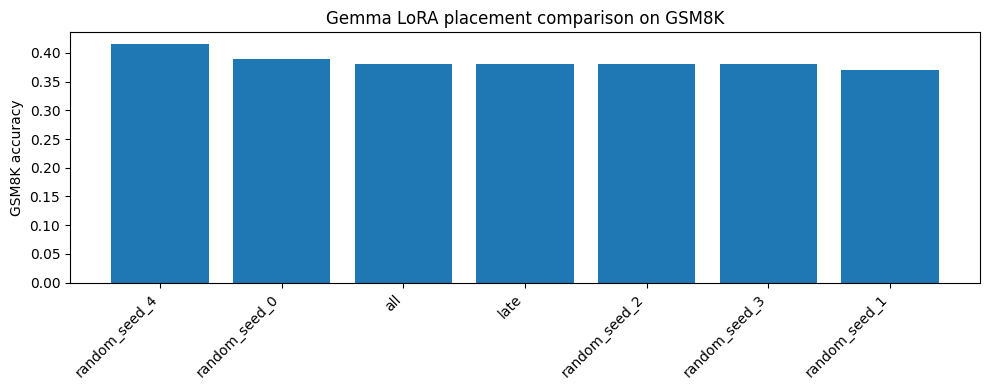

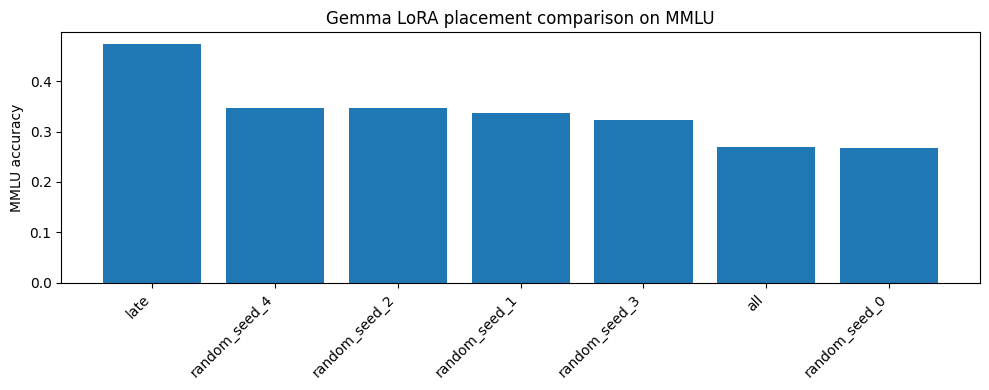

In [23]:
plt.figure(figsize=(10, 4))
plt.bar(gsm8k_summary["checkpoint"], gsm8k_summary["gsm8k_acc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("GSM8K accuracy")
plt.title("Gemma LoRA placement comparison on GSM8K")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(mmlu_summary["checkpoint"], mmlu_summary["mmlu_acc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("MMLU accuracy")
plt.title("Gemma LoRA placement comparison on MMLU")
plt.tight_layout()
plt.show()

## Save summary CSVs

In [24]:
results_dir = Path(f"./{MODEL_CFG['output_prefix']}-results")
results_dir.mkdir(parents=True, exist_ok=True)

gsm8k_summary.to_csv(results_dir / "gsm8k_summary.csv", index=False)
mmlu_summary.to_csv(results_dir / "mmlu_summary.csv", index=False)
gsm8k_grouped.to_csv(results_dir / "gsm8k_grouped_summary.csv", index=False)
mmlu_grouped.to_csv(results_dir / "mmlu_grouped_summary.csv", index=False)

print("Saved:")
for name in [
    "gsm8k_summary.csv",
    "mmlu_summary.csv",
    "gsm8k_grouped_summary.csv",
    "mmlu_grouped_summary.csv",
]:
    print(results_dir / name)

Saved:
gemma-gsm8k-robustness-results/gsm8k_summary.csv
gemma-gsm8k-robustness-results/mmlu_summary.csv
gemma-gsm8k-robustness-results/gsm8k_grouped_summary.csv
gemma-gsm8k-robustness-results/mmlu_grouped_summary.csv
